# Extreme Countix-AV dataset explorer

This notebook analyses the Extreme Countix-AV test annotations together with the locally available videos and extracted WAV tracks.


## 1. Setup

Place the notebook in the Extreme Countix-AV project root, next to `annotations/`, `videos/`, and `audios/`. Edit the paths below only if your layout differs.


In [1]:
from pathlib import Path
from urllib.parse import quote
import html
import json
import re
import shutil
import subprocess
import uuid
import wave

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SPLIT_ORDER = ["test"]
SPLIT_COLORS = {"test": "#10b981"}
VIDEO_SUFFIXES = {".mp4", ".mkv", ".webm", ".mov", ".m4v", ".avi"}
AUDIO_SUFFIXES = {".wav"}


In [2]:
ANNOTATIONS_DIR = Path("annotations")
VIDEO_ROOT = Path("videos")
AUDIO_ROOT = Path("audios")

print(f"Annotations: {ANNOTATIONS_DIR.resolve()}")
print(f"Videos:      {VIDEO_ROOT.resolve()}")
print(f"Audio:       {AUDIO_ROOT.resolve()}")


Annotations: /mnt/Workspace/audiovisual-video-repetition-counting/data/ExtremeCountixAV/annotations
Videos:      /mnt/Workspace/audiovisual-video-repetition-counting/data/ExtremeCountixAV/videos
Audio:       /mnt/Workspace/audiovisual-video-repetition-counting/data/ExtremeCountixAV/audios


## 2. Load and prepare annotations

Extreme Countix-AV provides a test set. Frame and second coordinates in the converted CSV are local to the stored cropped video.


In [3]:
REQUIRED_COLUMNS = [
    "video_name",
    "count",
    "class",
    "fps",
    "repetition_segment_start_sec",
    "repetition_segment_end_sec",
    "repetition_segment_start_frame",
    "repetition_segment_end_frame",
]


def find_extreme_csv(directory):
    preferred = [
        directory / "ExtremeCountixAV_test.csv",
    ]
    for path in preferred:
        if path.is_file():
            return path
    matches = sorted(
        path
        for path in directory.glob("*.csv")
        if "extreme" in path.stem.lower() and "test" in path.stem.lower()
    )
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one Extreme Countix-AV test CSV in {directory}; "
            f"found {len(matches)}."
        )
    return matches[0]


def source_video_id(video_name):
    # Preserve the Extreme clip name while grouping suffixes such as .00.
    stem = Path(str(video_name)).stem
    return re.sub(r"\.\d+$", "", stem)


annotation_path = find_extreme_csv(ANNOTATIONS_DIR)
annotations = pd.read_csv(annotation_path).copy()

missing = set(REQUIRED_COLUMNS) - set(annotations.columns)
if missing:
    raise ValueError(
        f"{annotation_path}: missing columns: {', '.join(sorted(missing))}"
    )

repetition_frame_columns = [
    column
    for column in annotations.columns
    if re.fullmatch(r"rep_\d+_(start|end)_frame", column)
]
numeric_columns = [
    "count",
    "fps",
    "repetition_segment_start_sec",
    "repetition_segment_end_sec",
    "repetition_segment_start_frame",
    "repetition_segment_end_frame",
    *repetition_frame_columns,
]
for column in numeric_columns:
    annotations[column] = pd.to_numeric(annotations[column], errors="coerce")

annotations["class"] = annotations["class"].fillna("unknown").astype(str)
annotations.loc[annotations["class"].str.strip().eq(""), "class"] = "unknown"
annotations["split"] = pd.Categorical(
    ["test"] * len(annotations), SPLIT_ORDER, ordered=True
)
annotations["row_in_split"] = np.arange(len(annotations))
annotations["clip_stem"] = annotations["video_name"].map(
    lambda name: Path(str(name)).stem
)
annotations["video_id"] = annotations["clip_stem"]
annotations["source_video_id"] = annotations["video_name"].map(source_video_id)

annotations["repetition_start_local_sec"] = annotations[
    "repetition_segment_start_sec"
]
annotations["repetition_end_local_sec"] = annotations[
    "repetition_segment_end_sec"
]
annotations["repetition_duration_sec"] = (
    annotations["repetition_end_local_sec"]
    - annotations["repetition_start_local_sec"]
)
annotations["mean_cycle_duration_sec"] = (
    annotations["repetition_duration_sec"] / annotations["count"]
)

rep_indices = [
    int(match.group(1))
    for column in repetition_frame_columns
    if (match := re.fullmatch(r"rep_(\d+)_start_frame", column))
]
maximum_rep_column = max(rep_indices, default=0)

print(f"Annotation file: {annotation_path}")
print(f"Loaded rows:     {len(annotations):,}")
print(f"Unique clips:    {annotations['clip_stem'].nunique():,}")
print(f"Rep columns:     1–{maximum_rep_column}")


Annotation file: annotations/ExtremeCountixAV_test.csv
Loaded rows:     215
Unique clips:    215
Rep columns:     1–54


/tmp/ipykernel_3668194/2091754651.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  annotations["split"] = pd.Categorical(
/tmp/ipykernel_3668194/2091754651.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  annotations["row_in_split"] = np.arange(len(annotations))
/tmp/ipykernel_3668194/2091754651.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To ge

## 3. Dataset overview

The summary separates annotation rows, Extreme clips, and original YouTube sources. Repetition durations are computed from the local segment timestamps.


In [4]:
overview = pd.DataFrame(
    {
        "value": [
            len(annotations),
            annotations["clip_stem"].nunique(),
            annotations["source_video_id"].nunique(),
            annotations["count"].sum(),
            annotations["count"].median(),
            annotations["count"].max(),
            annotations["repetition_duration_sec"].median(),
            annotations["mean_cycle_duration_sec"].median(),
            annotations["class"].eq("unknown").sum(),
        ]
    },
    index=[
        "Annotation rows",
        "Unique Extreme clips",
        "Unique source videos",
        "Annotated repetitions",
        "Median count",
        "Maximum count",
        "Median repetition window (s)",
        "Median cycle duration (s)",
        "Rows with unknown class",
    ],
)
display(overview.round(3))


,value
Annotation rows,215.000
Unique Extreme clips,215.000
Unique source videos,205.000
Annotated repetitions,"2,306.000"
Median count,7.000
Maximum count,54.000
Median repetition window (s),6.773
Median cycle duration (s),0.844
Rows with unknown class,57.000


### Annotation distributions

These plots show the count distribution, repetition-window duration, and the most frequent action classes in the Extreme test set.


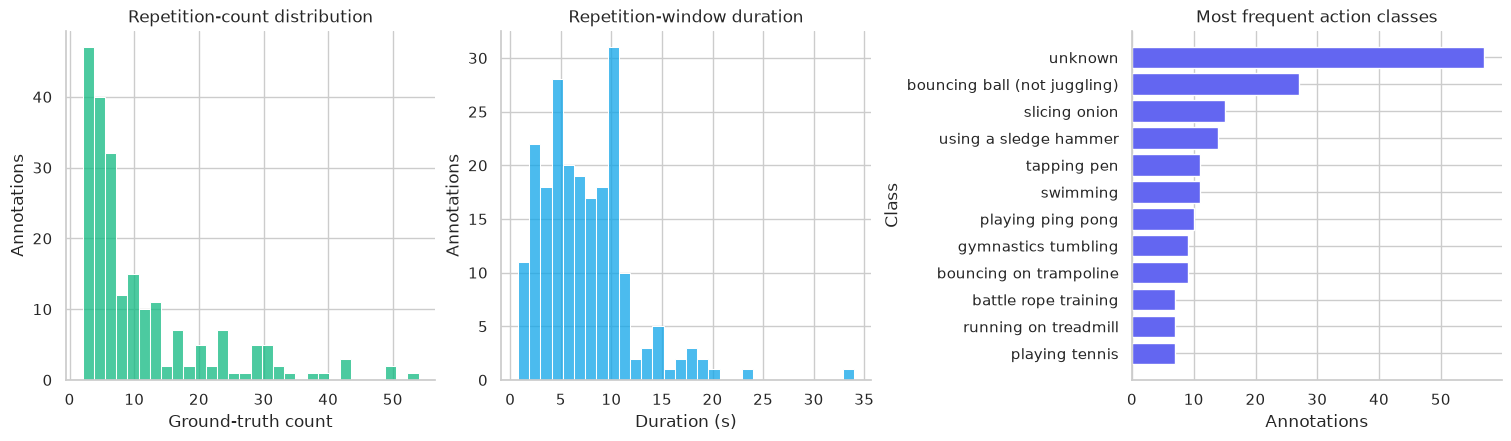

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

sns.histplot(
    data=annotations,
    x="count",
    bins=min(30, max(10, annotations["count"].nunique())),
    color="#10b981",
    ax=axes[0],
)
axes[0].set(
    title="Repetition-count distribution",
    xlabel="Ground-truth count",
    ylabel="Annotations",
)

sns.histplot(
    data=annotations,
    x="repetition_duration_sec",
    bins=30,
    color="#0ea5e9",
    ax=axes[1],
)
axes[1].set(
    title="Repetition-window duration",
    xlabel="Duration (s)",
    ylabel="Annotations",
)

class_counts = annotations["class"].value_counts().head(12).sort_values()
axes[2].barh(class_counts.index, class_counts.values, color="#6366f1")
axes[2].set(
    title="Most frequent action classes",
    xlabel="Annotations",
    ylabel="Class",
)

sns.despine()
plt.show()


## 4. Video and audio inventory

Media are matched by the complete Extreme clip stem, for example `3Q0K84jmKKA.00`. Video duration is probed with FFprobe; WAV metadata are read without decoding the full signal.


In [6]:
def build_media_index(root, suffixes):
    index = {}
    if not root.is_dir():
        return index
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in suffixes:
            index.setdefault(path.stem, []).append(path)
    for paths in index.values():
        paths.sort()
    return index


def choose_exact_path(index, clip_stem):
    matches = index.get(str(clip_stem), [])
    return matches[0] if matches else None


def probe_video(path):
    ffprobe = shutil.which("ffprobe")
    if ffprobe is None:
        return {
            "video_duration_sec": np.nan,
            "video_probe_error": "ffprobe is not available on PATH",
        }
    result = subprocess.run(
        [
            ffprobe,
            "-v", "error",
            "-show_entries", "format=duration",
            "-of", "json",
            str(path),
        ],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        return {
            "video_duration_sec": np.nan,
            "video_probe_error": result.stderr.strip() or "ffprobe failed",
        }
    try:
        duration = float(json.loads(result.stdout)["format"]["duration"])
    except Exception as exc:
        return {
            "video_duration_sec": np.nan,
            "video_probe_error": f"{type(exc).__name__}: {exc}",
        }
    return {"video_duration_sec": duration, "video_probe_error": ""}


def probe_wav(path):
    try:
        with wave.open(str(path), "rb") as handle:
            channels = handle.getnchannels()
            sample_rate = handle.getframerate()
            sample_width_bytes = handle.getsampwidth()
            sample_frames = handle.getnframes()
        duration = sample_frames / sample_rate if sample_rate else np.nan
        return {
            "audio_duration_sec": duration,
            "sample_rate_hz": sample_rate,
            "channels": channels,
            "sample_width_bits": sample_width_bytes * 8,
            "audio_probe_error": "",
        }
    except Exception as exc:
        return {
            "audio_duration_sec": np.nan,
            "sample_rate_hz": np.nan,
            "channels": np.nan,
            "sample_width_bits": np.nan,
            "audio_probe_error": f"{type(exc).__name__}: {exc}",
        }


video_index = build_media_index(VIDEO_ROOT, VIDEO_SUFFIXES)
audio_index = build_media_index(AUDIO_ROOT, AUDIO_SUFFIXES)

unique_clips = annotations[["clip_stem"]].drop_duplicates().reset_index(drop=True)
inventory_rows = []
for clip_stem in unique_clips["clip_stem"]:
    video_path = choose_exact_path(video_index, clip_stem)
    audio_path = choose_exact_path(audio_index, clip_stem)
    record = {
        "clip_stem": clip_stem,
        "video_path": video_path,
        "audio_path": audio_path,
        "video_available": video_path is not None,
        "audio_available": audio_path is not None,
        "video_matches": len(video_index.get(clip_stem, [])),
        "audio_matches": len(audio_index.get(clip_stem, [])),
    }
    record.update(
        probe_video(video_path)
        if video_path is not None
        else {"video_duration_sec": np.nan, "video_probe_error": ""}
    )
    record.update(
        probe_wav(audio_path)
        if audio_path is not None
        else {
            "audio_duration_sec": np.nan,
            "sample_rate_hz": np.nan,
            "channels": np.nan,
            "sample_width_bits": np.nan,
            "audio_probe_error": "",
        }
    )
    inventory_rows.append(record)

media_inventory = pd.DataFrame(inventory_rows)
media_inventory["audio_duration_error_sec"] = (
    media_inventory["audio_duration_sec"] - media_inventory["video_duration_sec"]
)
media_inventory["absolute_audio_duration_error_sec"] = media_inventory[
    "audio_duration_error_sec"
].abs()

available_audio = media_inventory.loc[media_inventory["audio_available"]]
media_overview = pd.DataFrame(
    {
        "value": [
            len(media_inventory),
            int(media_inventory["video_available"].sum()),
            int(media_inventory["audio_available"].sum()),
            media_inventory["video_available"].mean(),
            media_inventory["audio_available"].mean(),
            media_inventory["video_duration_sec"].median(),
            available_audio["sample_rate_hz"].nunique(dropna=True),
            available_audio["channels"].nunique(dropna=True),
            int(media_inventory["video_probe_error"].ne("").sum()),
            int(media_inventory["audio_probe_error"].ne("").sum()),
        ]
    },
    index=[
        "Expected clips",
        "Videos found",
        "WAV files found",
        "Video coverage",
        "Audio coverage",
        "Median stored video duration (s)",
        "Distinct sample rates",
        "Distinct channel counts",
        "Video probe failures",
        "Audio probe failures",
    ],
)
display(media_overview.round(3))


,value
Expected clips,215.000
Videos found,215.000
WAV files found,215.000
Video coverage,1.000
Audio coverage,1.000
Median stored video duration (s),7.241
Distinct sample rates,1.000
Distinct channel counts,1.000
Video probe failures,0.000
Audio probe failures,0.000


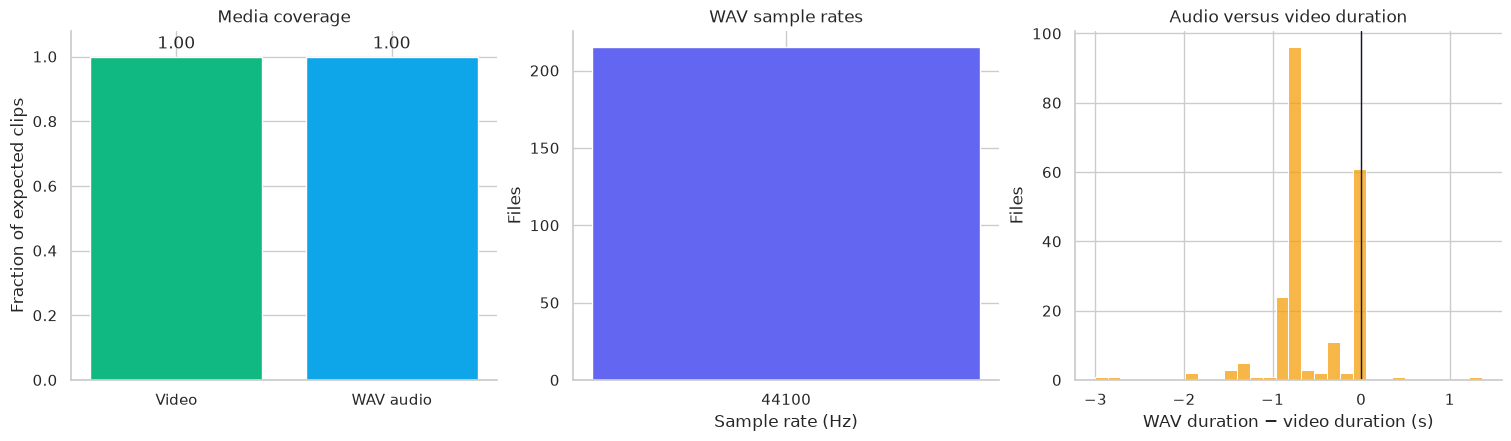

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

coverage_values = [
    media_inventory["video_available"].mean(),
    media_inventory["audio_available"].mean(),
]
axes[0].bar(["Video", "WAV audio"], coverage_values, color=["#10b981", "#0ea5e9"])
axes[0].bar_label(axes[0].containers[0], fmt="%.2f", padding=3)
axes[0].set(title="Media coverage", ylabel="Fraction of expected clips", ylim=(0, 1.08))

sample_rate_counts = available_audio["sample_rate_hz"].value_counts().sort_index()
axes[1].bar(sample_rate_counts.index.astype(str), sample_rate_counts.values, color="#6366f1")
axes[1].set(title="WAV sample rates", xlabel="Sample rate (Hz)", ylabel="Files")

duration_errors = media_inventory["audio_duration_error_sec"].dropna()
if len(duration_errors):
    sns.histplot(duration_errors, bins=30, color="#f59e0b", ax=axes[2])
    axes[2].axvline(0, color="#111827", linewidth=1)
axes[2].set(
    title="Audio versus video duration",
    xlabel="WAV duration − video duration (s)",
    ylabel="Files",
)

sns.despine()
plt.show()


## 5. Annotation and media checks

These checks cover repetition validity, per-repetition intervals, duplicate rows, missing media, probe errors, and audiovisual duration alignment.


In [8]:
annotations_with_duration = annotations.merge(
    media_inventory[["clip_stem", "video_duration_sec"]],
    on="clip_stem",
    how="left",
)
invalid_repetition = annotations["repetition_segment_end_frame"].le(
    annotations["repetition_segment_start_frame"]
)
invalid_count = annotations["count"].le(0) | annotations["count"].isna()
repetition_outside_video = (
    annotations_with_duration["video_duration_sec"].notna()
    & (
        annotations_with_duration["repetition_start_local_sec"].lt(-0.05)
        | annotations_with_duration["repetition_end_local_sec"].gt(
            annotations_with_duration["video_duration_sec"] + 0.05
        )
    )
)


def missing_repetition_pairs(row):
    if pd.isna(row["count"]) or row["count"] <= 0:
        return True
    for index in range(1, int(round(row["count"])) + 1):
        start_key = f"rep_{index}_start_frame"
        end_key = f"rep_{index}_end_frame"
        if (
            start_key not in row.index
            or end_key not in row.index
            or pd.isna(row[start_key])
            or pd.isna(row[end_key])
        ):
            return True
    return False


rows_with_missing_rep_pairs = annotations.apply(missing_repetition_pairs, axis=1)
checks = pd.DataFrame(
    {
        "diagnostic": [
            "Rows with missing required values",
            "Rows with invalid repetition intervals",
            "Repetition windows outside local video bounds",
            "Rows with non-positive counts",
            "Rows missing one or more per-repetition intervals",
            "Rows with unknown action class",
            "Exact duplicate annotation rows",
            "Expected clips without a video",
            "Expected clips without a WAV file",
            "Video files that could not be probed",
            "WAV files that could not be probed",
            "Audio/video duration differs by more than 0.25 s",
            "WAV files that are not mono",
            "WAV files not sampled at 16 kHz",
        ],
        "affected": [
            int(annotations[REQUIRED_COLUMNS].isna().any(axis=1).sum()),
            int(invalid_repetition.sum()),
            int(repetition_outside_video.sum()),
            int(invalid_count.sum()),
            int(rows_with_missing_rep_pairs.sum()),
            int(annotations["class"].eq("unknown").sum()),
            int(annotations.duplicated(subset=REQUIRED_COLUMNS).sum()),
            int((~media_inventory["video_available"]).sum()),
            int((~media_inventory["audio_available"]).sum()),
            int(media_inventory["video_probe_error"].ne("").sum()),
            int(media_inventory["audio_probe_error"].ne("").sum()),
            int(media_inventory["absolute_audio_duration_error_sec"].gt(0.25).sum()),
            int(available_audio["channels"].ne(1).sum()),
            int(available_audio["sample_rate_hz"].ne(16000).sum()),
        ],
    }
)
display(checks)

missing_videos = media_inventory.loc[
    ~media_inventory["video_available"], ["clip_stem"]
].reset_index(drop=True)
missing_audios = media_inventory.loc[
    ~media_inventory["audio_available"], ["clip_stem"]
].reset_index(drop=True)
audiovisual_duration_mismatches = media_inventory.loc[
    media_inventory["absolute_audio_duration_error_sec"].gt(0.25),
    [
        "clip_stem",
        "video_duration_sec",
        "audio_duration_sec",
        "audio_duration_error_sec",
        "video_path",
        "audio_path",
    ],
].reset_index(drop=True)


,diagnostic,affected
0,Rows with missing required values,0
1,Rows with invalid repetition intervals,0
2,Repetition windows outside local video bounds,0
3,Rows with non-positive counts,0
4,Rows missing one or more per-repetition intervals,0
5,Rows with unknown action class,57
6,Exact duplicate annotation rows,0
7,Expected clips without a video,0
8,Expected clips without a WAV file,0
9,Video files that could not be probed,0


## 6. Select examples

The table selects low-, median-, and high-count test annotations, preferring examples for which both video and audio are available.


In [9]:
annotations_with_media = annotations.merge(
    media_inventory[
        [
            "clip_stem",
            "video_available",
            "audio_available",
            "video_path",
            "audio_path",
            "video_duration_sec",
            "audio_duration_sec",
        ]
    ],
    on="clip_stem",
    how="left",
)

complete = annotations_with_media.loc[
    annotations_with_media["video_available"]
    & annotations_with_media["audio_available"]
]
candidates = complete if len(complete) else annotations_with_media
candidates = candidates.sort_values("count")

example_rows = []
if len(candidates):
    positions = {
        "low count": 0,
        "median count": len(candidates) // 2,
        "high count": len(candidates) - 1,
    }
    for label, position in positions.items():
        row = candidates.iloc[position]
        example_rows.append(
            {
                "selection": label,
                "row_in_test": int(row["row_in_split"]),
                "clip_stem": row["clip_stem"],
                "class": row["class"],
                "count": row["count"],
                "repetition_window_sec": row["repetition_duration_sec"],
                "video": bool(row["video_available"]),
                "audio": bool(row["audio_available"]),
            }
        )

examples = pd.DataFrame(example_rows)
display(examples)


,selection,row_in_test,clip_stem,class,count,repetition_window_sec,video,audio
0,low count,4,1D7frgXM1qE.00,bouncing ball (not juggling),2.000,4.176,True,True
1,median count,19,5BzNU_RTfsI.00,bouncing ball (not juggling),7.000,6.540,True,True
2,high count,110,1u0XZLcBcp0.00,slicing onion,54.000,8.919,True,True


## 7. Synchronized video, audio waveform, and annotation

The player keeps the video, audio waveform, repetition window, individual repetition intervals, and moving playheads synchronized. Click either track to seek.


In [10]:
def get_annotation_row(split="test", row_number=0):
    frame = annotations_with_media.loc[annotations_with_media["split"].eq(split)]
    if not 0 <= row_number < len(frame):
        raise IndexError(
            f"row_number must be between 0 and {len(frame) - 1} for {split}."
        )
    return frame.iloc[row_number]


def notebook_relative_url(path):
    try:
        relative = Path(path).resolve().relative_to(Path.cwd().resolve())
    except ValueError:
        return None
    return quote(relative.as_posix(), safe="/")


def wav_duration_seconds(path):
    with wave.open(str(path), "rb") as handle:
        sample_rate = handle.getframerate()
        frame_count = handle.getnframes()
    if sample_rate <= 0:
        raise ValueError("WAV sample rate is unavailable")
    return frame_count / sample_rate


def read_waveform_envelope(path, max_bins=900):
    with wave.open(str(path), "rb") as handle:
        channels = handle.getnchannels()
        sample_width = handle.getsampwidth()
        frame_count = handle.getnframes()
        raw = handle.readframes(frame_count)

    if sample_width == 1:
        samples = np.frombuffer(raw, dtype=np.uint8).astype(np.float32) - 128
    elif sample_width == 2:
        samples = np.frombuffer(raw, dtype="<i2").astype(np.float32)
    elif sample_width == 3:
        bytes_ = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3)
        values = (
            bytes_[:, 0].astype(np.int32)
            | (bytes_[:, 1].astype(np.int32) << 8)
            | (bytes_[:, 2].astype(np.int32) << 16)
        )
        values = np.where(values & 0x800000, values - 0x1000000, values)
        samples = values.astype(np.float32)
    elif sample_width == 4:
        samples = np.frombuffer(raw, dtype="<i4").astype(np.float32)
    else:
        raise ValueError(f"Unsupported WAV sample width: {sample_width} bytes")

    if channels > 1:
        samples = samples.reshape(-1, channels).mean(axis=1)
    if not len(samples):
        return np.array([0.0]), np.array([0.0])
    peak = float(np.max(np.abs(samples)))
    if peak > 0:
        samples = samples / peak

    bin_count = min(max_bins, len(samples))
    edges = np.linspace(0, len(samples), bin_count + 1, dtype=int)
    minima = np.empty(bin_count, dtype=float)
    maxima = np.empty(bin_count, dtype=float)
    for index in range(bin_count):
        chunk = samples[edges[index] : edges[index + 1]]
        minima[index] = chunk.min() if len(chunk) else 0.0
        maxima[index] = chunk.max() if len(chunk) else 0.0
    return minima, maxima


def waveform_polygon(minima, maxima, width=1000, height=140):
    if len(minima) == 1:
        x_values = np.array([0.0])
    else:
        x_values = np.linspace(0, width, len(minima))
    upper = [
        f"{x:.2f},{height * (0.5 - 0.43 * value):.2f}"
        for x, value in zip(x_values, maxima)
    ]
    lower = [
        f"{x:.2f},{height * (0.5 - 0.43 * value):.2f}"
        for x, value in zip(x_values[::-1], minima[::-1])
    ]
    return " ".join(upper + lower)


def show_extreme_countixav_example(split="test", row_number=0):
    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    audio_path = row.get("audio_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        print(f"Video not found for {row['clip_stem']}")
        return

    video_url = notebook_relative_url(video_path)
    if video_url is None:
        print("The video is outside the Jupyter server root.")
        print("Start Jupyter from the project root or one of its parents.")
        return

    # Use the WAV duration immediately; browser metadata will replace it with
    # the exact video duration as soon as the video is loaded.
    annotation_duration = float(row.get("video_duration_sec", np.nan))
    duration = (
        annotation_duration
        if np.isfinite(annotation_duration) and annotation_duration > 0
        else max(float(row["repetition_end_local_sec"]), 0.001)
    )
    # Video duration defines the visual timeline. A shorter WAV must not
    # truncate the repetition annotations.
    if (
        (not np.isfinite(annotation_duration) or annotation_duration <= 0)
        and isinstance(audio_path, Path)
        and audio_path.is_file()
    ):
        try:
            measured_audio_duration = wav_duration_seconds(audio_path)
            if np.isfinite(measured_audio_duration) and measured_audio_duration > 0:
                duration = measured_audio_duration
        except Exception:
            pass

    fps = float(row.get("fps", 30.0))
    repetition_start = max(0.0, float(row["repetition_start_local_sec"]))
    repetition_end = min(duration, float(row["repetition_end_local_sec"]))
    window_left = 100 * repetition_start / duration
    window_width = 100 * (repetition_end - repetition_start) / duration

    action_class = str(row.get("class", "unknown"))
    video_filename = str(row.get("video_name", video_path.name))

    count_val = int(round(float(row.get("count", 0))))
    repetition_blocks_html = ""
    
    if count_val > 0 and fps > 0:
        segment_start_sec = repetition_start
        segment_end_sec = repetition_end
        total_segment_duration = segment_end_sec - segment_start_sec
        
        if total_segment_duration > 0:
            for i in range(1, count_val + 1):
                start_frame_key = f"rep_{i}_start_frame"
                end_frame_key = f"rep_{i}_end_frame"
                
                if start_frame_key in row and end_frame_key in row and not pd.isna(row[start_frame_key]):
                    f_start = float(row[start_frame_key])
                    f_end = float(row[end_frame_key])
                    
                    rep_s = f_start / fps
                    rep_e = f_end / fps
                else:
                    rep_s = segment_start_sec + (i - 1) * total_segment_duration / count_val
                    rep_e = segment_start_sec + i * total_segment_duration / count_val
                
                rep_left = max(0.0, 100 * rep_s / duration)
                rep_w = max(0.0, 100 * (rep_e - rep_s) / duration)
                
                repetition_blocks_html += f'''
                  <div class="single-repetition" data-start="{rep_s:.9f}" data-end="{rep_e:.9f}" style="left: {rep_left:.4f}%; width: {rep_w:.4f}%;" title="Rep {i}">
                    <span>{i}</span>
                  </div>
                '''

    waveform_points = ""
    waveform_note = "WAV not available"
    if isinstance(audio_path, Path) and audio_path.is_file():
        try:
            minima, maxima = read_waveform_envelope(audio_path)
            waveform_points = waveform_polygon(minima, maxima)
            waveform_note = html.escape(audio_path.name)
        except Exception as exc:
            waveform_note = html.escape(f"Waveform unavailable: {exc}")

    uid = f"extreme-countixav-{uuid.uuid4().hex}"
    player = f'''
    <div id="{uid}" class="countixav-player" data-duration="{duration:.9f}"
         data-repetition-start="{repetition_start:.9f}"
         data-repetition-end="{repetition_end:.9f}">
      <style>
        #{uid} {{ max-width:1000px; font-family:system-ui,sans-serif; color:#f8fafc; background:#1e293b; padding:16px; border-radius:12px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); }}
        #{uid} .meta {{ display:flex; flex-wrap:wrap; gap:10px 20px; margin:0 0 12px; font-size:14px; background:#0f172a; padding:10px 14px; border-radius:8px; border: 1px solid #334155; }}
        #{uid} .meta span {{ color:#e2e8f0; }}
        #{uid} .meta strong {{ font-weight:600; color:#38bdf8; }}
        #{uid} video {{ display:block; width:100%; max-height:560px; background:#000000; border-radius:8px; }}
        #{uid} .wave-wrap {{ position:relative; margin-top:12px; height:140px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} svg {{ display:block; width:100%; height:100%; }}
        #{uid} .annotation {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; background:rgba(245,158,11,.25); border-left:2px solid #f59e0b; border-right:2px solid #f59e0b; pointer-events:none; }}
        #{uid} .playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .track-label {{ margin-top:12px; color:#cbd5e1; font-size:13px; font-weight:600; }}
        #{uid} .timeline {{ position:relative; height:42px; margin-top:4px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} .repetition-window {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; display:flex; align-items:center; justify-content:center; overflow:hidden; background:rgba(245,158,11,0.2); border-left:1px dashed #f59e0b; border-right:1px dashed #f59e0b; }}
        #{uid} .single-repetition {{ position:absolute; top:2px; bottom:2px; background:#f59e0b; border:1px solid #b45309; border-radius:3px; display:flex; align-items:center; justify-content:center; box-sizing: border-box; }}
        #{uid} .single-repetition span {{ color:#0f172a; font-size:10px; font-weight:700; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; padding:0 2px; }}
        #{uid} .timeline-playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .axis {{ display:flex; justify-content:space-between; margin-top:4px; color:#94a3b8; font-size:12px; }}
        #{uid} .status {{ margin-top:6px; color:#e2e8f0; font-size:13px; min-height:20px; font-weight:500; }}
        #{uid} .audio-note {{ color:#94a3b8; font-size:12px; margin-top:3px; }}
      </style>
      <div class="meta">
        <span><strong>Clip:</strong> {html.escape(str(row['clip_stem']))}</span>
        <span><strong>Video File:</strong> {html.escape(video_filename)}</span>
        <span><strong>Action Class:</strong> {html.escape(action_class)}</span>
        <span><strong>Split:</strong> {html.escape(str(row['split']))}</span>
        <span><strong>Count:</strong> {float(row['count']):g}</span>
        <span><strong>Window:</strong> {repetition_start:.3f}–{repetition_end:.3f} s</span>
      </div>
      <video controls preload="metadata" src="{video_url}"></video>
      <div class="wave-wrap" role="slider" aria-label="Audio waveform and repetition window"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <svg viewBox="0 0 1000 140" preserveAspectRatio="none" role="img" aria-label="Audio waveform">
          <line x1="0" y1="70" x2="1000" y2="70" stroke="#64748b" stroke-width="1" />
          <polygon points="{waveform_points}" fill="#38bdf8" opacity="0.8" />
        </svg>
        <div class="annotation" data-start="{repetition_start:.9f}" data-end="{repetition_end:.9f}" aria-hidden="true"></div>
        <div class="playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="audio-note">Waveform: {waveform_note}</div>
      <div class="track-label">Annotated repetitions breakdown</div>
      <div class="timeline" role="slider" aria-label="Annotated repetition timeline"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <div class="repetition-window"></div>
        {repetition_blocks_html}
        <div class="timeline-playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="status" aria-live="polite">0.000 s · before the annotated window</div>
      <script>
        (() => {{
          const root = document.getElementById({json.dumps(uid)});
          const video = root.querySelector('video');
          const waveform = root.querySelector('.wave-wrap');
          const playhead = root.querySelector('.playhead');
          const annotation = root.querySelector('.annotation');
          const timeline = root.querySelector('.timeline');
          const timelinePlayhead = root.querySelector('.timeline-playhead');
          const repetitionBlocks = root.querySelectorAll('.single-repetition');
          const axisEnds = root.querySelectorAll('.axis-end');
          const status = root.querySelector('.status');
          let duration = Number(root.dataset.duration);
          const repetitionStart = Number(root.dataset.repetitionStart);
          const repetitionEnd = Number(root.dataset.repetitionEnd);
          let animationFrame = null;

          const layoutRange = (element, start, end) => {{
            const safeStart = Math.min(Math.max(start, 0), duration);
            const safeEnd = Math.min(Math.max(end, safeStart), duration);
            element.style.left = `${{100 * safeStart / duration}}%`;
            element.style.width = `${{100 * (safeEnd - safeStart) / duration}}%`;
          }};

          const layoutTracks = () => {{
            layoutRange(
              annotation,
              Number(annotation.dataset.start),
              Number(annotation.dataset.end),
            );
            repetitionBlocks.forEach(block => {{
              layoutRange(block, Number(block.dataset.start), Number(block.dataset.end));
            }});
            waveform.setAttribute('aria-valuemax', duration.toFixed(3));
            timeline.setAttribute('aria-valuemax', duration.toFixed(3));
            axisEnds.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
          }};

          const useVideoDuration = () => {{
            const measuredDuration = Number(video.duration);
            if (Number.isFinite(measuredDuration) && measuredDuration > 0) {{
              duration = measuredDuration;
              root.dataset.duration = measuredDuration.toFixed(9);
              layoutTracks();
            }}
          }};

          const update = () => {{
            const t = Math.min(Math.max(video.currentTime || 0, 0), duration);
            playhead.style.left = `${{100 * t / duration}}%`;
            timelinePlayhead.style.left = `${{100 * t / duration}}%`;
            waveform.setAttribute('aria-valuenow', t.toFixed(3));
            timeline.setAttribute('aria-valuenow', t.toFixed(3));
            if (t < repetitionStart) {{
              status.textContent = `${{t.toFixed(3)}} s · before the annotated window`;
            }} else if (t <= repetitionEnd) {{
              status.textContent = `${{t.toFixed(3)}} s · inside the annotated window`;
            }} else {{
              status.textContent = `${{t.toFixed(3)}} s · after the annotated window`;
            }}
          }};

          const animate = () => {{
            update();
            if (!video.paused && !video.ended) {{
              animationFrame = requestAnimationFrame(animate);
            }}
          }};

          const seekFromTrack = (event, track) => {{
            const bounds = track.getBoundingClientRect();
            video.currentTime = duration * (event.clientX - bounds.left) / bounds.width;
            update();
          }};
          waveform.addEventListener('click', event => seekFromTrack(event, waveform));
          timeline.addEventListener('click', event => seekFromTrack(event, timeline));
          video.addEventListener('play', () => {{
            if (animationFrame !== null) cancelAnimationFrame(animationFrame);
            animate();
          }});
          video.addEventListener('pause', update);
          video.addEventListener('ended', update);
          video.addEventListener('seeked', update);
          video.addEventListener('loadedmetadata', () => {{
            useVideoDuration();
            update();
          }});
          layoutTracks();
          update();
        }})();
      </script>
    </div>
    '''
    display(HTML(player))

In [11]:
# Change this value to inspect another annotation row from the Extreme test set.
EXAMPLE_SPLIT = "test"
EXAMPLE_ROW = 18

show_extreme_countixav_example(EXAMPLE_SPLIT, EXAMPLE_ROW)


`EXAMPLE_ROW` refers to the original row order in the Extreme test CSV. The browser must be able to serve both the notebook and media files from the same Jupyter root.


In [12]:
# Canva export: set the toggle to True to render the selected Extreme example as an MP4.
# The export contains the video, WAV audio, waveform, repetition window, and moving cursors.
EXPORT_CANVA_MP4 = True
CANVA_EXPORT_DIR = Path("canva_exports")


def export_canva_mp4(
    split=EXAMPLE_SPLIT,
    row_number=EXAMPLE_ROW,
    output_dir=CANVA_EXPORT_DIR,
    fps=30,
):
    import shutil
    import subprocess
    import tempfile

    def probe_duration(path, ffprobe_executable):
        """Return the container duration reported by FFprobe, or NaN."""
        if ffprobe_executable is None:
            return float("nan")
        probe = subprocess.run(
            [
                ffprobe_executable,
                "-v", "error",
                "-show_entries", "format=duration",
                "-of", "default=noprint_wrappers=1:nokey=1",
                str(path),
            ],
            capture_output=True,
            text=True,
        )
        if probe.returncode != 0:
            return float("nan")
        try:
            value = float(probe.stdout.strip())
        except (TypeError, ValueError):
            return float("nan")
        return value if np.isfinite(value) and value > 0 else float("nan")

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg is None:
        raise RuntimeError(
            "FFmpeg is required for MP4 export. Install it and restart the kernel."
        )

    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    audio_path = row.get("audio_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        raise FileNotFoundError(f"Video not found for {row['clip_stem']}")
    if not isinstance(audio_path, Path) or not audio_path.is_file():
        raise FileNotFoundError(f"WAV audio not found for {row['clip_stem']}")

    # Use the real media duration rather than the nominal 10 s Kinetics window.
    video_duration = probe_duration(video_path, ffprobe)
    audio_duration = probe_duration(audio_path, ffprobe)
    if not np.isfinite(audio_duration):
        audio_duration = wav_duration_seconds(audio_path)

    # Video defines the visual timeline. A shorter WAV is padded with
    # silence instead of truncating the video and repetition intervals.
    if np.isfinite(video_duration) and video_duration > 0:
        duration = video_duration
    elif np.isfinite(audio_duration) and audio_duration > 0:
        duration = audio_duration
    else:
        duration = max(float(row["repetition_end_local_sec"]), 0.001)

    if not np.isfinite(duration) or duration <= 0:
        raise ValueError(f"Invalid clip duration: {duration}")

    repetition_start = np.clip(
        float(row["repetition_start_local_sec"]), 0.0, duration
    )
    repetition_end = np.clip(
        float(row["repetition_end_local_sec"]), repetition_start, duration
    )
    minima, maxima = read_waveform_envelope(audio_path, max_bins=1600)
    waveform_duration = (
        audio_duration
        if np.isfinite(audio_duration) and audio_duration > 0
        else duration
    )
    times = np.linspace(0.0, waveform_duration, len(minima))

    # Recreate the same numbered repetition blocks used by the HTML player.
    repetition_intervals = []
    count_val = int(round(float(row.get("count", 0))))
    metadata_fps = float(row.get("fps", 30.0))
    repetition_window_duration = repetition_end - repetition_start
    if count_val > 0 and metadata_fps > 0 and repetition_window_duration > 0:
        for repetition_index in range(1, count_val + 1):
            start_key = f"rep_{repetition_index}_start_frame"
            end_key = f"rep_{repetition_index}_end_frame"
            if (
                start_key in row
                and end_key in row
                and not pd.isna(row[start_key])
                and not pd.isna(row[end_key])
            ):
                interval_start = float(row[start_key]) / metadata_fps
                interval_end = float(row[end_key]) / metadata_fps
            else:
                interval_start = repetition_start + (
                    (repetition_index - 1) * repetition_window_duration / count_val
                )
                interval_end = repetition_start + (
                    repetition_index * repetition_window_duration / count_val
                )

            interval_start = float(np.clip(interval_start, 0.0, duration))
            interval_end = float(np.clip(interval_end, interval_start, duration))
            if interval_end > interval_start:
                repetition_intervals.append(
                    (repetition_index, interval_start, interval_end)
                )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{row['clip_stem']}_canva.mp4"

    with tempfile.TemporaryDirectory(prefix="extreme_countixav_canva_") as temp_dir:
        panel_path = Path(temp_dir) / "tracks.png"

        # Match the dark HTML player: 1920 x 320 px panel below a 760 px video.
        panel_width_px = 1920
        panel_height_px = 320
        track_left_px = 32
        track_width_px = 1856
        waveform_top_px = 12
        waveform_height_px = 140
        timeline_top_px = 210
        timeline_height_px = 42

        figure = plt.figure(
            figsize=(panel_width_px / 100, panel_height_px / 100),
            dpi=100,
            facecolor="#1e293b",
        )
        waveform_axis = figure.add_axes(
            [
                track_left_px / panel_width_px,
                (panel_height_px - waveform_top_px - waveform_height_px)
                / panel_height_px,
                track_width_px / panel_width_px,
                waveform_height_px / panel_height_px,
            ]
        )
        repetition_axis = figure.add_axes(
            [
                track_left_px / panel_width_px,
                (panel_height_px - timeline_top_px - timeline_height_px)
                / panel_height_px,
                track_width_px / panel_width_px,
                timeline_height_px / panel_height_px,
            ]
        )

        waveform_axis.set_facecolor("#334155")
        waveform_axis.fill_between(
            times, minima, maxima, color="#38bdf8", alpha=0.8, linewidth=0
        )
        waveform_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.25,
            linewidth=0,
        )
        waveform_axis.axvline(repetition_start, color="#f59e0b", linewidth=2)
        waveform_axis.axvline(repetition_end, color="#f59e0b", linewidth=2)
        waveform_axis.axhline(0, color="#64748b", linewidth=1)
        waveform_axis.set(
            xlim=(0, duration),
            ylim=(-1.05, 1.05),
            xticks=[],
            yticks=[],
        )

        repetition_axis.set_facecolor("#334155")
        repetition_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.20,
            linewidth=0,
        )
        repetition_axis.axvline(
            repetition_start, color="#f59e0b", linewidth=1, linestyle="--"
        )
        repetition_axis.axvline(
            repetition_end, color="#f59e0b", linewidth=1, linestyle="--"
        )
        for repetition_index, interval_start, interval_end in repetition_intervals:
            repetition_axis.axvspan(
                interval_start,
                interval_end,
                ymin=0.05,
                ymax=0.95,
                facecolor="#f59e0b",
                edgecolor="#b45309",
                linewidth=1,
                alpha=1.0,
            )
            repetition_axis.text(
                (interval_start + interval_end) / 2,
                0.5,
                str(repetition_index),
                ha="center",
                va="center",
                color="#0f172a",
                fontsize=10,
                fontweight="bold",
                clip_on=True,
            )
        repetition_axis.set(
            xlim=(0, duration),
            ylim=(0, 1),
            xticks=[],
            yticks=[],
        )

        for axis in (waveform_axis, repetition_axis):
            for spine in axis.spines.values():
                spine.set_visible(False)

        # Labels mirror the typography and ordering of the notebook player.
        label_x_left = track_left_px / panel_width_px
        label_x_right = (track_left_px + track_width_px) / panel_width_px
        figure.text(label_x_left, 0.493, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            label_x_right,
            0.493,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.text(
            label_x_left,
            0.435,
            f"Waveform: {audio_path.name}",
            color="#94a3b8",
            fontsize=9,
        )
        figure.text(
            label_x_left,
            0.355,
            "Annotated repetitions breakdown",
            color="#cbd5e1",
            fontsize=10,
            fontweight="bold",
        )
        figure.text(label_x_left, 0.145, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            label_x_right,
            0.145,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.savefig(
            panel_path,
            dpi=100,
            facecolor=figure.get_facecolor(),
            edgecolor="none",
        )
        plt.close(figure)

        track_left = float(track_left_px)
        track_width = float(track_width_px)
        cursor_x = f"{track_left}+(t/{duration:.9f})*{track_width}"
        filter_graph = (
            "[0:v]setpts=PTS-STARTPTS,"
            "scale=1920:760:force_original_aspect_ratio=decrease,"
            "pad=1920:760:(ow-iw)/2:(oh-ih)/2:color=0x0b1020,"
            "format=yuv420p[video];"
            "[1:v]setpts=PTS-STARTPTS,fps={fps},scale=1920:320,"
            "format=yuv420p[panel];"
            "[video][panel]vstack=inputs=2:shortest=1[base];"
            "color=c=0xef4444:s=4x140:r={fps}[wave_cursor];"
            "[base][wave_cursor]overlay=x='{cursor_x}':y=772:shortest=1[first];"
            "color=c=0xef4444:s=4x42:r={fps}[rep_cursor];"
            "[first][rep_cursor]overlay=x='{cursor_x}':y=970:shortest=1[outv]"
        ).format(fps=int(fps), cursor_x=cursor_x)

        command = [
            ffmpeg,
            "-y",
            "-i",
            str(video_path),
            "-loop",
            "1",
            "-framerate",
            str(int(fps)),
            "-i",
            str(panel_path),
            "-i",
            str(audio_path),
            "-filter_complex",
            filter_graph,
            "-map",
            "[outv]",
            "-map",
            "2:a:0",
            "-t",
            f"{duration:.9f}",
            "-r",
            str(int(fps)),
            "-c:v",
            "libx264",
            "-preset",
            "medium",
            "-crf",
            "18",
            "-pix_fmt",
            "yuv420p",
            "-af",
            "apad",
            "-c:a",
            "aac",
            "-b:a",
            "192k",
            "-movflags",
            "+faststart",
            str(output_path),
        ]
        result = subprocess.run(command, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(
                "FFmpeg export failed:\n" + result.stderr[-5000:]
            )

    print(f"Canva-ready MP4: {output_path.resolve()}")
    return output_path


if EXPORT_CANVA_MP4:
    CANVA_MP4_PATH = export_canva_mp4()
else:
    print("Set EXPORT_CANVA_MP4 = True and run this cell to create the MP4.")


Canva-ready MP4: /mnt/Workspace/audiovisual-video-repetition-counting/data/ExtremeCountixAV/canva_exports/1yv3uYO9lOQ.00_canva.mp4
